In [3]:
!pip install seaborn

✅ Loaded 3,883 unique movies.
✅ Loaded 1,000,209 user interaction reviews.


/var/folders/5l/mggy4p1d24xdv34wh9my8xzm0000gq/T/ipykernel_33542/3022628252.py:40: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/inka.saavuori/matrix-factorization/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


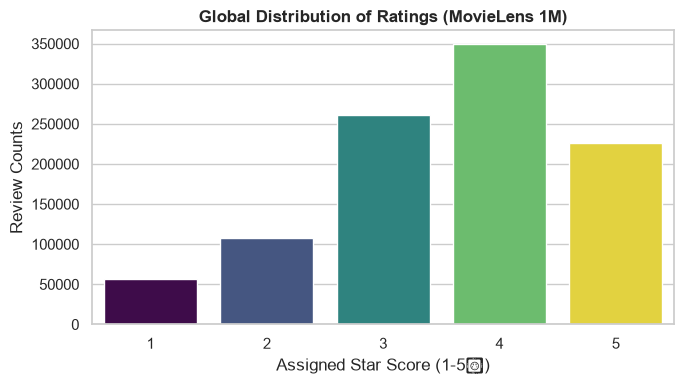

📊 Dataset Global Mean Score (μ): 3.5816 stars
📈 Ratings of 4★ or 5★ make up 57.52% of all logs.


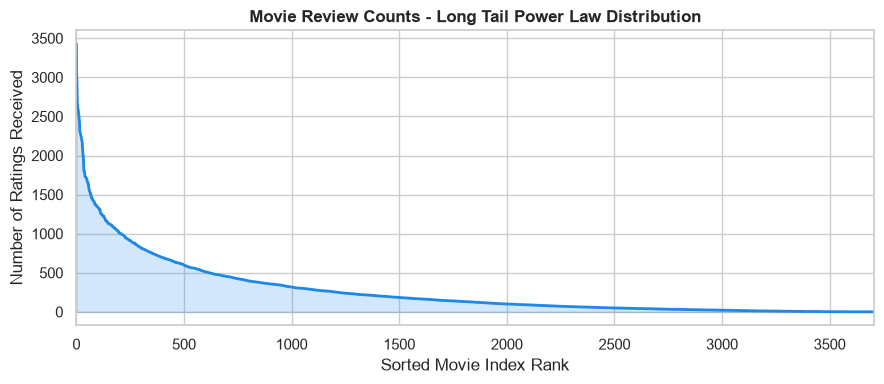

👥 Total Active Unique Users: 6040
🎬 Total Active Unique Movies: 3706
🌌 Total Matrix Interaction Grid Points: 22,384,240
📉 Calculated Matrix Sparsity Deficit: 95.53% empty slots.


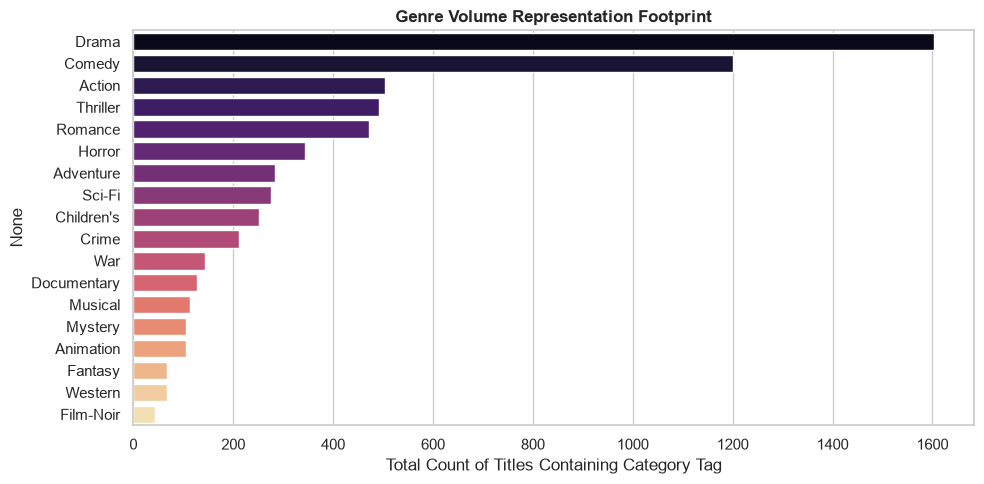

In [4]:
# %% [markdown]
# # 01.edu gritlab Matrix-factorization: Exploratory Data Analysis
# This notebook explores user rating distributions, dataset sparsity metrics, and demographic bias profiles 
# within the MovieLens 1M dataset to ground our collaborative filtering models.

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# %% [markdown]
# ## 1. Load Data Elements
# We leverage our existing `utils.data_loader` modules to fetch tracking assets.

# %%
from utils.data_loader import load_movies, load_ratings

movies = load_movies()
ratings = load_ratings()

print(f"✅ Loaded {len(movies):,} unique movies.")
print(f"✅ Loaded {len(ratings):,} user interaction reviews.")

# %% [markdown]
# ## 2. Global Rating Distribution Analysis
# Let's inspect the skewed nature of explicit feedback metrics across the entire engine pool.

# %%
plt.figure(figsize=(7, 4))
sns.countplot(data=ratings, x="rating", hue="rating", palette="viridis", legend=False)
plt.title("Global Distribution of Ratings (MovieLens 1M)", fontsize=12, fontweight="bold")
plt.xlabel("Assigned Star Score (1-5★)")
plt.ylabel("Review Counts")
plt.tight_layout()
plt.show()

mean_rating = ratings["rating"].mean()
print(f"📊 Dataset Global Mean Score (μ): {mean_rating:.4f} stars")
print(f"📈 Ratings of 4★ or 5★ make up {len(ratings[ratings['rating'] >= 4]) / len(ratings) * 100:.2f}% of all logs.")

# %% [markdown]
# ## 3. Long-Tail Distribution (The Blockbuster Bias)
# Plotting rating volume per movie demonstrates why collaborative models naturally bias toward highly active mainstream titles.

# %%
movie_counts = ratings["movie_id"].value_counts().values

plt.figure(figsize=(9, 4))
plt.plot(movie_counts, color="#1E88E5", linewidth=2)
plt.fill_between(range(len(movie_counts)), movie_counts, color="#1E88E5", alpha=0.2)
plt.title("Movie Review Counts - Long Tail Power Law Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Sorted Movie Index Rank")
plt.ylabel("Number of Ratings Received")
plt.xlim(0, len(movie_counts))
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Sparsity Matrix Calculations
# Matrix Factorization exists because the user-item interaction grid is mostly completely empty.

# %%
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()
possible_interactions = num_users * num_movies
actual_interactions = len(ratings)

sparsity = (1 - (actual_interactions / possible_interactions)) * 100
print(f"👥 Total Active Unique Users: {num_users}")
print(f"🎬 Total Active Unique Movies: {num_movies}")
print(f"🌌 Total Matrix Interaction Grid Points: {possible_interactions:,}")
print(f"📉 Calculated Matrix Sparsity Deficit: {sparsity:.2f}% empty slots.")

# %% [markdown]
# ## 5. Core Genre Signature Analysis
# Let's extract the most heavily reviewed movie categories across our data footprint.

# %%
all_genres = []
for g_str in movies["genres"]:
    all_genres.extend(g_str.split("|"))

genre_series = pd.Series(all_genres).value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_series.values, y=genre_series.index, hue=genre_series.index, palette="magma", legend=False)
plt.title("Genre Volume Representation Footprint", fontsize=12, fontweight="bold")
plt.xlabel("Total Count of Titles Containing Category Tag")
plt.tight_layout()
plt.show()